# Google Colab
This notebook is intended to be executed on Google Golab.

In [ ]:
# setup for Google Colab
!pip install torch torchvision
!pip install requests
!pip install tqdm
!pip install Pillow
!pip install matplotlib

In [77]:
# imports
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import requests
import subprocess
import json

# MyDataset class
MyDataset class is a child of the pytorch Dataset class that provides access to tinyimagenet and places2 datasets.  
MyDataset class provide the posibility to switch from one dataset to another and from one split to another(train -> val, val -> train).  

Tinyimagenet was downloaded from [http://cs231n.stanford.edu/tiny-imagenet-200.zip](http://cs231n.stanford.edu/tiny-imagenet-200.zip), and places2 was downloaded from [https://www.kaggle.com/datasets/nickj26/places2-mit-dataset](https://www.kaggle.com/datasets/nickj26/places2-mit-dataset).  

For the tinyimagenet dataset i did the following:
- Downloaded the original archive from the provided link.
- Unpacked the archive locally.
- Originally, the dataset consists of two big train, val folders with many subfolders. For each train and val folder, i did not want to have subfolders, so i moved the images from the subfolders into the root train/val big folders and deleted all the subfolders. The final result are just the two big train and val folders with images inside, no subfolders.
- For each train, val, big folders i renamed the images with the following patters: 0.extension, 1.extension, 2.extension, etc. The reason behind is to make indexing easier.
Ex: for train: 0.extension, 1.extension, 2.extension,etc; for val: 0.extension, 1.extension, 2.extension. etc.
- Added train_index.json, val_index.json with a 'files' dictionary were key = the index('0', '1', '2','3', etc.), value = relative path to image('0':'train/0.jpeg for train_index.json; '0':'val/0.jpeg' for val_index.json and so on).
- Repacked train, val, folders + train_index.json, val_index.json into tinyimagenet_flat.tar and uploaded it to my student onedrive account.
- Save the link to download tinyimagenet_flat.tar to self.__datasets['tinyimagenet']['url']

For the places2 dataset:
- Downloaded the original archive from the provided link.
- Unpacked the archive locally.
- Originally, the dataset consists of two big train, val folders with many subfolders. For each train and val folder, i did not want to have subfolders, so i moved the images from the subfolders into the root train/val big folders and deleted all the subfolders. The final result are just the two big train and val folders with images inside, no subfolders.
- For each train, val, big folders i renamed the images with the following patters: 0.extension, 1.extension, 2.extension, etc. The reason behind is to make indexing easier.
Ex: for train: 0.extension, 1.extension, 2.extension,etc; for val: 0.extension, 1.extension, 2.extension. etc.
- The original archive had almost 30 GB in size. This is too big to use for this project, so i deleted images in both train and val subfolders, starting from the largest index(index.extension, where index - is the largest number) and counting backwards.
- Added train_index.json, val_index.json with a 'files' dictionary were key = the index('0', '1', '2','3', etc.), value = relative path to image('0':'train/0.jpeg for train_index.json; '0':'val/0.jpeg' for val_index.json and so on).
- Repacked train, val, folders + train_index.json, val_index.json into places2_reduced.tar. From the original 30GB archived, i got a final aprox 3GB .tar archive, uploaded it to my student onedrive account.
- Save the link to download tinyimagenet_flat.tar to self.__datasets['places2']['url']

The tinyimagenet dataset:
- train has 100000 images of 64x64 size
- val has 20000 images of 64x64 size
  
The place2_reduced dataset:
- train has 167000 images of 128x128 size
- val has 39000 images of 128x128 size

In both datasets a single image is in either train or val, not both.

In [100]:
class Images(Dataset):
    def __init__(self, dataset='places2', split='train'):
        super().__init__()
        self.__root_dir = Path().cwd() # /content on google colab
        self.__datasets = {
            'places2': {
                'name': 'places2',
                'url': 'https://ctipub-my.sharepoint.com/:u:/g/personal/marius_vlad_dumitru_stud_etti_upb_ro/IQDIXTjG7MdBRrMizEF0KjaWAR46T_nR4YNLuvv3HThlCN4?download=1',
                'archive': self.__root_dir / 'places2_reduced.tar',
                'extract_dir': self.__root_dir / 'places2'
            },
            'tinyimagenet': {
                'name': 'tinyimagenet',
                'url': 'https://ctipub-my.sharepoint.com/:u:/g/personal/marius_vlad_dumitru_stud_etti_upb_ro/IQBkCh4mNvQ8Q7t70sitsGOyAWD29CnOXxthhkGPnbmeRBY?download=1',
                'archive': self.__root_dir / 'tinyimagenet_flat.tar',
                'extract_dir': self.__root_dir / 'tinyimagenet'
            }
        }

        self.change_dataset(dataset)
        self.change_split(split)

    def __download_dataset(self):
        try:
            print(f"[INFO] Downloading dataset {self.__dataset['name']}. This may take a whike ...")
            response = requests.get(self.__dataset['url'], stream=True)
            response.raise_for_status()
            total_size = int(response.headers.get("Content-Length", 0))
            with open(str(self.__dataset['archive']), "wb") as f, tqdm(
                total=total_size,
                unit="B",
                unit_scale=True,
                desc="Downloading",
            ) as pbar:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
                        pbar.update(len(chunk))
            print(f"[INFO] Download complete: {str(self.__dataset['archive'])}")
            return True

        except Exception as e:
            print(f"[ERROR] Download failed: {e}")
            return False
    
    def __extract_dataset(self):
        try:
            print(f"[INFO] Extracting dataset {self.__dataset['archive']} into folder {self.__dataset['extract_dir']}. This may take a while ...")
            archive = self.__dataset['archive']
            out_dir = self.__dataset['extract_dir']
            out_dir.mkdir(parents=True, exist_ok=True)
            subprocess.run(
                ["tar", "-xf", str(archive), "-C", str(out_dir)],
                check=True
            )

            print(f"[INFO] Extraction complete: {out_dir}")
            return True

        except Exception as e:
            print(f"[ERROR] Extraction failed: {e}")
            return False
    
    def change_dataset(self, new_dataset):
        self.__dataset = self.__datasets[new_dataset] 
        if not self.__dataset['archive'].exists():
            self.__download_dataset()
        if not self.__dataset['extract_dir'].exists():
            self.__extract_dataset()
        
    def get_dataset(self):
        return self.__dataset['name']
        
    def change_split(self, new_split):
        self.__split = new_split
        json_name = self.__split + '_index.json'
        json_path =  self.__dataset['extract_dir'] / json_name
        with json_path.open() as f:
            self.__json_data = json.load(f)

    def get_split(self):
        return self.__split

    def __len__(self):
        return len(self.__json_data['files'])
    
    def __getitem__(self, idx):
        if idx > self.__len__() - 1 : # idx: [0, self.__len__() - 1]
            raise Exception(f'{idx} out of bound. Valid range is [0, {self.__len__() - 1}]')
        img_path = self.__dataset['extract_dir'] / self.__json_data['files'][str(idx)]
        image = Image.open(img_path).convert("RGB") # image loaded from disk
        transform = T.ToTensor()  # converts to [C, H, W] in range [0, 1]
        tensor_img = transform(image) 
        return tensor_img # pytorch tensor [C, H, W] in range [0, 1]


Current dataset is: places2
Current split for places2 dataset is: train
Total number of images for dataset places2 with the split train is: 167000
Changing split to val for dataset places2

Current dataset is: places2
Current split for places2 dataset is: val
Total number of images for dataset places2 with the split val is: 39000

Current dataset is: tinyimagenet
Current split for tinyimagenet dataset is: train
Total number of images for dataset tinyimagenet with the split train is: 100000
Changing split to val for dataset tinyimagenet

Current dataset is: tinyimagenet
Current split for tinyimagenet dataset is: val
Total number of images for dataset tinyimagenet with the split val is: 20000

tensor([[[0.9765, 0.9765, 0.4353,  ..., 0.1255, 0.7686, 0.9373],
         [0.9765, 0.9765, 0.4510,  ..., 0.1255, 0.7804, 0.9373],
         [0.9804, 0.9765, 0.4863,  ..., 0.1294, 0.8118, 0.9451],
         ...,
         [0.9804, 0.9569, 1.0000,  ..., 1.0000, 0.9490, 1.0000],
         [0.9608, 0.9765

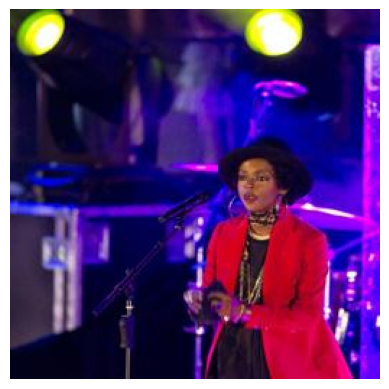


Showing an image from dataset places2, split val


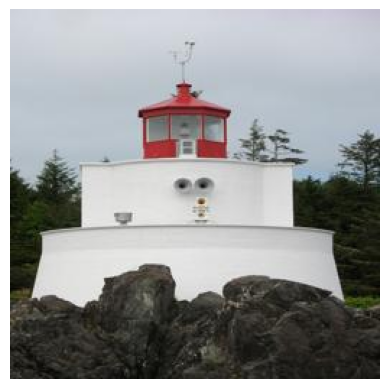


Showing an image from dataset tinyimagenet, split train


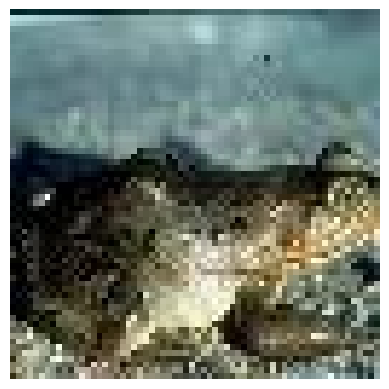


Showing an image from dataset tinyimagenet, split val


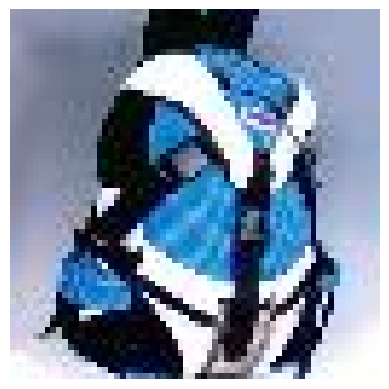

In [ ]:
# Testing Images Dataset class
def print_images_info(images_obj):
    print()
    print(f'Current dataset is: {images_obj.get_dataset()}')
    print(f'Current split for {images_obj.get_dataset()} dataset is: {images_obj.get_split()}')
    print(f'Total number of images for dataset {images_obj.get_dataset()} with the split {images_obj.get_split()} is: {images_obj.__len__()}')

images_obj = Images()
print_images_info(images_obj)
print(f'Changing split to val for dataset {images_obj.get_dataset()}')
images_obj.change_split('val')
print_images_info(images_obj)

images_obj.change_dataset('tinyimagenet')
images_obj.change_split('train')
print_images_info(images_obj)
print(f'Changing split to val for dataset {images_obj.get_dataset()}')
images_obj.change_split('val')
print_images_info(images_obj)
print()
print(images_obj[5])

def show_tensor(tensor):
    plt.imshow(tensor.permute(1, 2, 0))  # [C,H,W] → [H,W,C]
    plt.axis("off")
    plt.show()

images_obj.change_dataset('places2')
images_obj.change_split('train')
print(f'Showing an image from dataset {images_obj.get_dataset()}, split {images_obj.get_split()}')
show_tensor(images_obj[50])
print()
images_obj.change_split('val')
print(f'Showing an image from dataset {images_obj.get_dataset()}, split {images_obj.get_split()}')
show_tensor(images_obj[550])
print()
images_obj.change_dataset('tinyimagenet')
images_obj.change_split('train')
print(f'Showing an image from dataset {images_obj.get_dataset()}, split {images_obj.get_split()}')
show_tensor(images_obj[1000])
print()
images_obj.change_split('val')
print(f'Showing an image from dataset {images_obj.get_dataset()}, split {images_obj.get_split()}')
show_tensor(images_obj[10])
print()

In [113]:
places2 = Images(dataset='places2', split='train')
tinyimagenet = Images(dataset='tinyimagenet', split='train')